# Beispiel 19.1: Berechnung der Reduktion eines Oxids nach dem isothermen Modell des schrumpfenden Kerns 

Bearbeitet von Marcel Broocks 

Dieses Beispiel befindet sich im Lehrbuch auf den Seiten 307 - 308 und behandelt die Reduktion eines kugelförmigen Oxidpartikels ($\rho = 32{,}81 \, \mathrm{kmol \, m^{-3}}$) bei einer Temperatur von $T = 400 \, \mathrm{°C}$ in einem Wasserstoffstrom ($c_{\mathrm{1,b}} = 17{,}87 \, \mathrm{mol \, m^{-3}})$. Es wird davon ausgegangen, dass die Reaktion äquimolar ($\nu_1 = \nu_2$) abläuft, weiterhin betrage die Reaktionsgeschwindigkeitskonstante $k_{\mathrm{s}} = 0{,}05 \, \mathrm{m \, s^{-1}}$, der Stoffübergangskoeffizient für die Gasphase $k_{\mathrm{1,G}} = 0{,}05 \, \mathrm{m \, s^{-1}}$ und der effektive Diffusionskoeffizient in der entstehenden porösen Schicht des festen Produktes $D_{\mathrm{1,eff}} = 1 \cdot 10^{-5} \, \mathrm{m^2 \, s^{-1}}$. <br> Die Nummerierung der im Lösungsvorschlag verwendeten Gleichungen sowie Tabellen entspricht der des Lehrbuchs. 

# Importieren der benötigten Pakete
Bevor mit der Berechnung gestartet werden kann, müssen zur Bearbeitung des Beispiels folgende Pakete importiert werden:

- numpy
    - Zur Durchführung von numerischen Rechenoperationen und zum Arbeiten mit Arrays
    - Informationen unter https://numpy.org/doc/stable/reference/routines.array-creation.html
- matplotlib
    - Zum Erstellen von Grafiken
    - Informationen unter https://matplotlib.org/stable/tutorials/introductory/index.html
- scipy
    - Zur Durchführung wissenschaftlicher Rechnungen (hier zur Lösung von DGLs mithilfe des Runge-Kutta-Verfahrens)
    - Informationen unter https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html

Diese Pakete werden nun importiert und alle gegebenen Größen implementiert.

In [1]:
# Importieren der benötigten Pakete 
import numpy as np                           # numerische Rechenoperationen
import matplotlib.pyplot as plt              # Darstellung von Diagrammen 
from scipy.integrate import solve_ivp        # Lösen von DGLs
from matplotlib.ticker import FuncFormatter  # Achsenbeschriftung 

# Implementierung der gegebenen Größen
rho = 32.81                                  # Partikeldichte / kmol m^-3
T = 400                                      # Temperatur / °C
c_1b = 17.87                                 # Konzentration des Wasserstoffstroms / mol m^-3
nu_1 = nu_2 = -1                             # st. Koeffizienten / - (äquimolare Reaktion)
k_s = 0.05                                   # Reaktionsgeschwindigkeitskonstante / m s^-1
k_1G = 0.05                                  # Stoffübergangskoeffizient (Gasphase) / m s^-1
D_1eff = 1e-5                                # Diffusionskoeffizient / m^2 s^-1

Zunächst soll der Verlauf des Restanteils $f_1$ in Abhängigkeit von der dimensionslosen Ortskoordinate $\chi$ dargestellt werden, wofür die Gleichung (19.28) herangezogen wird.
$$
f_1 = f_{\mathrm{1,c}} + \dfrac{f_{\mathrm{1,s}} - f_{\mathrm{1,c}}}{1 - \chi_{\mathrm{c}}}
\left(1 - \dfrac{\chi_{\mathrm{c}}}{\chi}\right)
$$
Weiterhin sind die Definitionen von $f_{\mathrm{1,s}}$ und $f_{\mathrm{1,c}}$ durch Gl. (19.31a) bzw. (19.31b) bekannt und werden nun implementiert.
$$
f_{\mathrm{1,s}} = \dfrac{1 + \phi^2_{\mathrm{mod}} \, \chi_{\mathrm{c}} \, (1 - \chi_{\mathrm{c}})}{1 + \frac{\phi^2_{\mathrm{mod}}}{Bi_{\mathrm{1,m}}} \, \chi^2_{\mathrm{c}} + \phi^2_{\mathrm{mod}} \, \chi_{\mathrm{c}} \, (1 - \chi_{\mathrm{c}})} \quad \quad \quad \quad \quad 
f_{\mathrm{1,c}} = \dfrac{1}{1 + \frac{\phi^2_{\mathrm{mod}}}{Bi_{\mathrm{1,m}}} \, \chi^2_{\mathrm{c}} + \phi^2_{\mathrm{mod}} \, \chi_{\mathrm{c}} \, (1 - \chi_{\mathrm{c}})}
$$
Für die dimensionslosen Größen gilt dabei:
$$
Bi_{\mathrm{1,m}} = \dfrac{k_{\mathrm{1,G}} \, L}{D_{\mathrm{1,eff}}} \quad \mathrm{(19.14a)} \quad \quad \quad \quad \quad \phi^2_{\mathrm{mod}} = \dfrac{r_{\mathrm{mod,b}} \, L}{c_{\mathrm{1,b}} \, D_{\mathrm{1,eff}}} \quad \mathrm{(19.14c)} \quad \mathrm{mit} \quad r_{\mathrm{mod,b}} = k_{\mathrm{s}} \, c_{\mathrm{1,b}},
$$
wobei $L = d_{\mathrm{p}}/2$ ist. Wie in dem Beispiel beschrieben ist, beträgt die charakteristische Länge $L = 0{,}005 \, \mathrm{m}$.

In [2]:
L = 0.005                                    # charakteristische Länge / m

# Dimensionslose Größen
r_modb = k_s*c_1b                            # modifizierte Reaktionsgeschwindigkeit / mol m^-2 s^-1
Bi_1m = (k_1G*L)/D_1eff                      # Biot-Zahl (Materialbilanz) / -
Thiele_mod = (r_modb*L)/(c_1b*D_1eff)        # modifizierter Thiele-Modul / -  

# Gl. (19.28) über Definitionen (19.31a) und (19.31b)
def f1_s(chi_c): 
    return (1+Thiele_mod*chi_c*(1-chi_c))/(1+(Thiele_mod/Bi_1m)*chi_c**2+Thiele_mod*chi_c*(1-chi_c))

def f1_c(chi_c): 
    return 1/(1+(Thiele_mod/Bi_1m)*chi_c**2+Thiele_mod*chi_c*(1-chi_c))

def f1(chi, chi_c):
    return f1_c(chi_c)+((f1_s(chi_c)-f1_c(chi_c))/(1-chi_c))*(1-chi_c/chi)

Anschließend werden die Kurven für verschiedene Werte von $\chi_{\mathrm{c}}$ abgebildet. Außerdem wird eine Einhüllende aufgetragen, die die Funktion $f_1 \, (\chi_{\mathrm{c}})$ widerspiegelt.

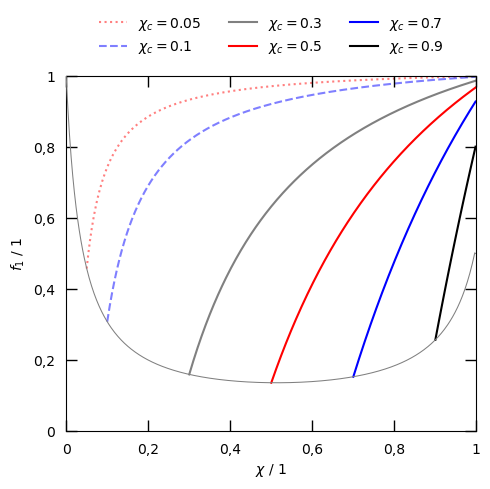

In [3]:
# Kurven für verschiedene chi_c
chi_c_values = [0.05, 0.1, 0.3, 0.5, 0.7, 0.9] # abgelesene Werte für chi_c
chi = np.linspace(0, 1, 500)                   # Einteilung der x-Achse (500 Auswertestellen)
colors = ['r', 'b', 'grey', 'r', 'b', 'k']     
transparence = [0.5, 0.5, 1, 1, 1, 1]           
linestyles = [':', '--', '-', '-', '-', '-']   

plt.figure(figsize=(5,5))

for i, chi_c in enumerate(chi_c_values):
    chi_plot = chi[chi >= chi_c]               # nur gültige Werte >= chi_c
    f_vals = np.array([f1(x, chi_c) for x in chi_plot])
    plt.plot(chi_plot, f_vals, label=fr'$\chi_c={chi_c}$', color=colors[i], alpha=transparence[i], linestyle=linestyles[i])

# Einhüllende plotten
f_einhuellend = np.zeros_like(chi)

for i, chi_val in enumerate(chi):              # wenn chi_val = 0 --> setze f = 1
    if chi_val <= 0:
        f_einhuellend[i] = 1
        continue

    chi_c_fine = np.linspace(0, chi_val, 500)      
    f_vals = []

    for cc in chi_c_fine:
        if chi_val == cc:
            val = f1_s(cc)
        else:
            val = f1(chi_val, cc)
        f_vals.append(val)
    f_einhuellend[i] = min(f_vals)

plt.plot(chi, f_einhuellend, color='grey', linewidth=0.75, zorder=10)

# Achsenbeschriftung + Achsenskalierung
plt.xlabel(r'$\chi$ / 1')
plt.ylabel(r'$f_1$ / 1')
plt.axis([0, 1, 0, 1])
# Trennzeichen auf Achse (,)
def format_with_comma(x, pos):
    if abs(x) < 0.2: return '0'
    elif abs(x) > 0.8: return '1'
    return f"{x:.1f}".replace('.', ',')
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_with_comma))
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_with_comma))
# Achsenticks zeigen nach innen (liegen vor den Kurven), Grid ist ausgeschaltet
plt.gca().set_axisbelow(False)
plt.tick_params(direction='in', top=True, right=True, length=8, width=1)
plt.tick_params(axis='x', pad=8)
plt.tick_params(axis='y', pad=8)
plt.grid(False)
# Legende einfügen 
plt.legend(loc='lower left', bbox_to_anchor=(0.05,1.02), ncols=3, frameon=False)
plt.tight_layout()
plt.show()

Darüber hinaus soll der Verlauf von $\chi_{\mathrm{c}}$ und $U$ gegenüber dem Quotienten $\frac{\theta}{\theta\, (\chi_{\mathrm{c}} = 0)}$ aufgetragen werden. Dafür wird die Differentialgleichung (19.32)
$$
\dfrac{d\chi_{\mathrm{c}}}{d\theta} = - f_{\mathrm{1,c}}
$$
mithilfe von solve_ivp, unter Verwendung des Runge-Kutta-Verfahrens 4. Ordnung (RK45), gelöst. Der Umsatzgrad berechnet sich nach Gl. (19.12) des Lehrbuchs wie folgt:
$$
U = 1 - \chi_{\mathrm{c}}^3.
$$

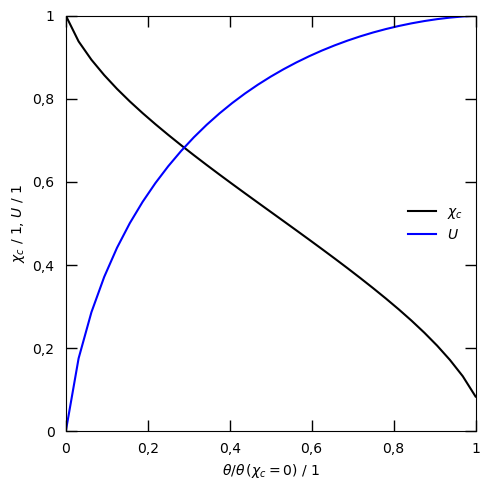

In [4]:
def DGL(theta, chi_c): # Gl. (19.32)
    return -f1_c(chi_c)

# Event-Funktion, Division durch 0 zu vermeiden und numerische Stabilität zu gewährleisten
def stop_at_zero(theta, chi_c):
    return chi_c[0] - 1e-8
stop_at_zero.terminal = True
stop_at_zero.direction = -1
result = solve_ivp(DGL, [0, 500], [1.0], t_eval=np.linspace(0, 500, 3000), method='RK45', events=stop_at_zero)

# Herausziehen der Ergebnisse
theta_vals = result.t
chi_c_vals = result.y[0]

# Umsatzgrad nach Gl. (19.12)
U_vals = 1 - chi_c_vals**3

# Abbildung plotten mit normierter x-Achse, nähere Beschreibung ist oben zu finden
plt.figure(figsize=(5,5))
plt.plot(theta_vals/theta_vals[-1], chi_c_vals, 'k', label=r'$\chi_c$')  
plt.plot(theta_vals/theta_vals[-1], U_vals, 'b', label=r'$U$')       

plt.xlabel(r'$\theta / \theta \,(\chi_c=0)$ / 1')
plt.ylabel(r'$\chi_c$ / 1, $U$ / 1')
plt.axis([0, 1, 0, 1])
plt.legend(frameon=False)
def format_with_comma(x, pos):
    if abs(x) < 0.2: return '0'
    elif abs(x) > 0.8: return '1'
    return f"{x:.1f}".replace('.', ',')
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_with_comma))
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_with_comma))
plt.gca().set_axisbelow(False)
plt.tick_params(direction='in', top=True, right=True, length=8, width=1)
plt.tick_params(axis='x', pad=8)
plt.tick_params(axis='y', pad=8)
plt.grid(False)
plt.tight_layout()
plt.show()

Dem Diagramm kann entnommen werden, dass der Kernradius, bis auf den Beginn und das Ende der Reaktion, nahezu linear mit der relativen Reaktionszeit abnimmt. Dies hat einen starken Anstieg des Umsatzgrades zu Beginn der Reaktion zur Folge. 

Zur Auftragung der erforderlichen Reaktionszeit $t$ sowie der Zeiten für die limitierenden Teilschritte $t_{\mathrm{G}}$, $t_{\mathrm{P}}$ und $t_{\mathrm{R}}$ für unterschiedliche Partikeldurchmesser $d_{\mathrm{p}}$, wird die Tabelle 19.3 auf S. 306 benötigt.
\renewcommand{\arraystretch}{1.8}
$$
\begin{array}{l|c|c}
\hline
\mathrm{Limitierung\ durch} &
\mathrm{Reaktionszeit}\,(\chi_{\mathrm{c}}=0) &
\mathrm{Reaktionszeit}\,(\chi_{\mathrm{c}}) \\
\hline
\mathrm{Diffusion\ im\ Gasfilm} &
\theta_{\mathrm{G}}=\dfrac{1}{3}\dfrac{\phi_{\mathrm{mod}}^2}{Bi_{\mathrm{1,m}}} &
\theta_{\mathrm{G}}=\dfrac{1}{3}\dfrac{\phi_{\mathrm{mod}}^2}{Bi_{\mathrm{1,m}}}(1-\chi_{\mathrm{c}}^3) \\
\hline
\mathrm{Diffusion\ in\ Produktschicht} &
\theta_{\mathrm{P}}=\dfrac{1}{6}\phi_{\mathrm{mod}}^2 &
\theta_{\mathrm{P}}=\phi_{\mathrm{mod}}^2
\left(\dfrac{1}{6}-\dfrac{1}{2}\chi_{\mathrm{c}}^2+\dfrac{1}{3}\chi_{\mathrm{c}}^3\right) \\
\hline
\mathrm{Reaktion} &
\theta_{\mathrm{R}}=1 &
\theta_{\mathrm{R}}=1-\chi_{\mathrm{c}} \\
\hline
\mathrm{allgemeiner\ Fall:} \, \theta=\theta_{\mathrm{G}}+\theta_{\mathrm{P}}+\theta_{\mathrm{R}} &
\theta = \dfrac{1}{3}\dfrac{\phi_{\mathrm{mod}}^2}{Bi_{\mathrm{1,m}}}
+\dfrac{1}{6}\phi_{\mathrm{mod}}^2+1 &
\begin{aligned}
\theta={}&\dfrac{1}{3}\dfrac{\phi_{\mathrm{mod}}^2}{Bi_{\mathrm{1,m}}}
(1-\chi_{\mathrm{c}}^3)\\
&+\phi_{\mathrm{mod}}^2
\left(\dfrac{1}{6}-\dfrac{1}{2}\chi_{\mathrm{c}}^2+\dfrac{1}{3}\chi_{\mathrm{c}}^3\right)\\
&+1-\chi_{\mathrm{c}}
\end{aligned} \\
\hline
\end{array}
$$
Die Ausdrücke aus der Spalte für $\chi_{\mathrm{c}} = 0$ werden dann in die Gl. (19.26) 
$$
\theta = \dfrac{\nu_2}{\nu_1} \, \dfrac{r_{\mathrm{mod,b}} \, t}{L \, \rho}
$$
eingsetzt und nach der Zeit $t$ umgestellt. Daraus ergeben sich im Anschluss die folgenden Zusammenhänge:
$$
t_{\mathrm{G}} = \dfrac{1}{6} \, \dfrac{\rho}{c_{\mathrm{1,b}}} \, \dfrac{d_{\mathrm{p}}}{k_{\mathrm{1,G}}} \quad \quad \quad \quad \quad t_{\mathrm{P}} = \dfrac{1}{24} \, \dfrac{\rho}{c_{\mathrm{1,b}}} \, \dfrac{d^2_{\mathrm{p}}}{D_{\mathrm{1,eff}}} \quad \quad \quad \quad \quad t_{\mathrm{R}} = \dfrac{1}{2} \, \dfrac{\rho}{c_{\mathrm{1,b}}} \, \dfrac{d_{\mathrm{p}}}{k_{\mathrm{s}}}. 
$$

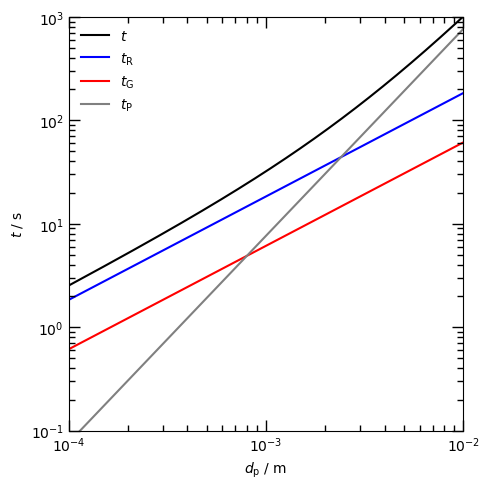

In [5]:
dp_vals = np.logspace(-4, -2, 1000)  # Partikeldurchmesser / m, logarithmische Auftragung

# Dimensionlose Größen mit neuem Durchmesser
r_modb = k_s*c_1b
Thiele_mod = (r_modb*(dp_vals/2))/(c_1b * D_1eff)
Bi_1m = (k_1G*(dp_vals/2))/D_1eff

# Berechnung nach Einsetzen in Gl. (19.26), Dichte mit 1000 multipliziert
t_G = (1/6)*(rho*1000*dp_vals)/(k_1G*c_1b)
t_P = (1/24)*(dp_vals**2*rho*1000)/(c_1b*D_1eff)
t_R = (1/2)*(rho*1000*dp_vals)/(r_modb)
t_total = t_G + t_P + t_R

# Abbildung plotten, nähere Beschreibung ist oben zu finden
plt.figure(figsize=(5,5))
plt.loglog(dp_vals, t_total, 'k', label=r'$t$')
plt.loglog(dp_vals, t_R, 'b', label=r'$t_{\mathrm{R}}$')
plt.loglog(dp_vals, t_G, 'r', label=r'$t_{\mathrm{G}}$')
plt.loglog(dp_vals, t_P, 'grey', label=r'$t_{\mathrm{P}}$')
plt.xlabel(r'$d_{\mathrm{p}}$ / m')
plt.ylabel(r'$t$ / s')
plt.legend(frameon=False)
plt.gca().set_axisbelow(False)
plt.axis([10**-4,10**-2,10**-1,10**3])
plt.minorticks_on()  # Neben-Skalierungen aktivieren
# Nur Hauptlinien als Grid zeichnen
plt.grid(False)
# Ticks konfigurieren: Major groß, Minor klein
plt.tick_params(which="major", direction="in", length=8, width=1, top=True, right=True)
plt.tick_params(which="minor", direction="in", length=4, width=1, top=True, right=True)
plt.tight_layout()
plt.show()

Aufgrund der Proportionalitäten der Reaktionszeiten bezüglich des Partikeldurchmessers, dominieren Filmdiffusion und Reaktion den Gesamtvorgang bei kleinen Partikeldurchmessern ($t_{\mathrm{G}}, t_{\mathrm{R}} \propto d_{\mathrm{p}})$, während mit zunehmender Partikelgröße die Produktschichtdiffusion immer mehr an Bedeutung gewinnt ($t_{\mathrm{P}} \propto d_{\mathrm{p}}^2$). Sie wird ab einem Durchmesser von ca. 2 mm der größte Widerstand.